# Scaling Sweeps For Classical Baselines And QSVT Proxies

This notebook sweeps finite-difference system size and inverse-polynomial degree for dense linear solve (DLS) and conjugate gradient solve (CGS) baselines. The output is a compact benchmark table suitable for docs or release artifacts.

In [1]:
from pathlib import Path

import numpy as np

from qsvt import (
    benchmark_summary_table,
    conjugate_gradient_benchmark,
    dense_linear_solve_benchmark,
    design_positive_inverse_polynomial,
    dirichlet_laplacian_1d,
    plot_benchmark_timings,
    plot_qsvt_proxy_resources,
    save_report,
    write_benchmark_summary_csv,
)


def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("could not locate repository root")


ROOT = find_repo_root()
ARTIFACT_DIR = ROOT / "results/benchmarks"
TABLE_DIR = ROOT / "results/tables"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


def fmt(value):
    if value is None:
        return "n/a"
    if isinstance(value, (list, tuple, set)):
        return ", ".join(fmt(item) for item in value)
    if isinstance(value, float):
        if value == 0.0:
            return "0"
        if abs(value) < 1e-3 or abs(value) >= 1e4:
            return f"{value:.2e}"
        return f"{value:.4g}"
    return str(value)


def display_table(title, rows, columns):
    rendered = [
        [str(header), *[fmt(accessor(row)) for row in rows]]
        for header, accessor in columns
    ]
    widths = [max(len(item) for item in row) for row in rendered]

    print(title)
    print("-" * len(title))
    for row, width in zip(rendered, widths):
        print(f"{row[0]:<{width}} : " + " | ".join(row[1:]))

## Dimension And Degree Sweep

## Quantum-Advantage Interpretation

Scaling sweeps are where the classical-vs-quantum question becomes concrete. DLS exposes the cubic small-system reference, while CGS exposes the sparse iterative baseline that a useful quantum algorithm must beat after accounting for block encoding, state preparation, precision, and measurement. The QSVT proxy is not a runtime claim; it tracks polynomial degree and signal calls so users can see whether a problem family is moving toward the regime where quantum signal processing might provide asymptotic leverage.

Scaling sweep readout
---------------------
Reports : 6
Matrix dimensions : 6, 10, 14
Max QSVT signal calls : 9


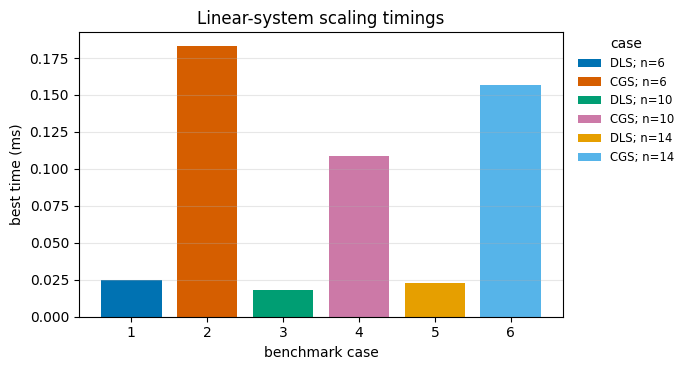

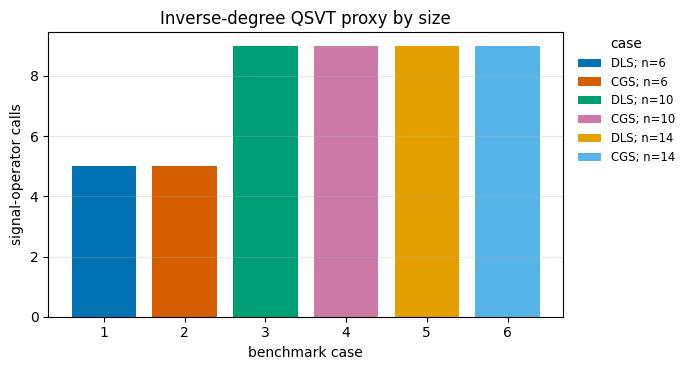

In [2]:
reports = []
for n in [6, 10, 14]:
    grid, operator = dirichlet_laplacian_1d(n)
    rhs = np.sin(np.pi * grid)
    eigenvalues = np.linalg.eigvalsh(operator)
    gamma = float(np.min(eigenvalues) / np.max(eigenvalues))
    degree = 5 if n == 6 else 9
    coeffs = design_positive_inverse_polynomial(gamma=gamma, degree=degree)

    reports.append(
        dense_linear_solve_benchmark(
            operator,
            rhs,
            repeats=2,
            qsvt_coeffs=coeffs,
        )
    )
    reports.append(
        conjugate_gradient_benchmark(
            operator,
            rhs,
            tolerance=1e-10,
            repeats=2,
            qsvt_coeffs=coeffs,
        )
    )

summary_rows = benchmark_summary_table(reports)
save_report(
    {"mode": "benchmark-scaling-sweep", "reports": reports},
    ARTIFACT_DIR / "scaling_sweep_reports.json",
)
write_benchmark_summary_csv(reports, TABLE_DIR / "benchmark_scaling_summary.csv")

summary = {
    "report_count": len(reports),
    "dimensions": sorted({row["matrix_dimension"] for row in summary_rows}),
    "max_qsvt_signal_calls": max(
        row["qsvt_signal_operator_calls"] for row in summary_rows
    ),
}
display_table(
    "Scaling sweep readout",
    [summary],
    [
        ("Reports", lambda row: row["report_count"]),
        ("Matrix dimensions", lambda row: row["dimensions"]),
        ("Max QSVT signal calls", lambda row: row["max_qsvt_signal_calls"]),
    ],
)

_ = plot_benchmark_timings(reports, title="Linear-system scaling timings")
_ = plot_qsvt_proxy_resources(reports, title="Inverse-degree QSVT proxy by size")